In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xml.etree.ElementTree as ET
import shapely
import cartopy
import pyproj
import numpy
from math import sin,cos,radians
from pathlib import Path
from datetime import datetime

In [2]:
title = "Seduisant WNR Series 2 4/22/2026"
outfileBase = "Seduisant WNR Series 2 2026-04-22"
outputPath = "./output/Seduisant"

waypointFile = "./tracks/2020LakePontchartrainRacingMarks.gpx"
trackFile = "./tracks/Track_2026-04-22 200035.gpx"
windFile = "./windData/burl1_2026-04-24.pickle"
proj = cartopy.crs.Mercator()
buffer = 0.25 / 60 #buffer in nautical miles
figsize = (25,8)
nm2Meter = 1852.0
norm = mpl.colors.Normalize(vmin=5, vmax = 9, clip=True)
colorbarTicks = numpy.arange(norm.vmin,norm.vmax+0.001,1.0)
colorMap = mpl.cm.magma

In [3]:
wgs84 = pyproj.crs.CRS.from_string('WGS84')
utm = pyproj.crs.CRS.from_string('EPSG:32615')

In [4]:
Path(outputPath).mkdir(exist_ok=True,parents=True)

In [5]:
waypointXML = ET.parse(waypointFile)

In [6]:
wptList = []
for child in waypointXML.getroot():
    data = {
                'name':child.find('{http://www.topografix.com/GPX/1/1}name').text,
                'geometry':shapely.Point(child.attrib['lon'],child.attrib['lat'])
    }
    
    wptList.append(data)

waypointGdf = gpd.GeoDataFrame(data= pd.DataFrame.from_dict(wptList), geometry='geometry', crs=wgs84)

In [7]:
waypointGdf.drop_duplicates(subset=['name'], inplace=True)

In [8]:
waypointGdf['name'] = waypointGdf['name'].str.replace('"','').str.replace('SYC ','')

In [9]:
waypointGdf.set_index('name', inplace=True)

In [10]:
trkXML = ET.parse(trackFile)

In [11]:
trkSegXML = trkXML.getroot().find('{http://www.topografix.com/GPX/1/1}trk').\
    find('{http://www.topografix.com/GPX/1/1}trkseg')

In [12]:
trkList = []
for child in trkSegXML:
    data = {
                'time':child.find('{http://www.topografix.com/GPX/1/1}time').text,
                'geometry':shapely.Point(child.attrib['lon'],child.attrib['lat'])
           }
    
    trkList.append(data)

trkGdf = gpd.GeoDataFrame(data=pd.DataFrame.from_dict(trkList), geometry='geometry', crs=wgs84)

In [13]:
trkGdf['time'] = pd.to_datetime( trkGdf['time'] ).dt.tz_convert('US/Central')
print(f"Start time {trkGdf['time'].min()}")

Start time 2026-04-22 18:19:40-05:00


In [14]:
trkGdf['timeDelta'] = trkGdf['time'] - trkGdf['time'].shift(1)
trkGdf['timeCumsum'] = trkGdf['timeDelta'].cumsum()
print(f"Mean time between measure {trkGdf['timeDelta'].mean()}")

Mean time between measure 0 days 00:00:05.952802


In [15]:
geod = pyproj.Geod(ellps='clrk66')
print(f"Total distance {geod.line_length(trkGdf['geometry'].x, trkGdf['geometry'].y) / nm2Meter}nm")

Total distance 11.455295432484897nm


In [16]:
trkGdf['bearing'] = geod.inv(trkGdf['geometry'].x,trkGdf['geometry'].y, trkGdf['geometry'].shift(1).x, trkGdf['geometry'].shift(1).y)[1]

In [17]:
mask = trkGdf['bearing'] < 0
trkGdf.loc[mask, 'bearing'] = trkGdf['bearing'][mask] + 360.0

In [18]:
trkGdf['delta_distance'] = numpy.nan
trkGdf.loc[1:,'delta_distance'] = geod.line_lengths(trkGdf['geometry'].x, trkGdf['geometry'].y) / nm2Meter

In [19]:
trkGdf['dist_cumsum'] = trkGdf['delta_distance'].cumsum()

In [20]:
trkGdf['delta_distance'].sum()

np.float64(11.455295432484878)

In [21]:
trkGdf['speed'] = (60.0 * 60.0 * trkGdf['delta_distance']) / trkGdf['timeDelta'].dt.total_seconds()

In [22]:
print(f"speed max:{trkGdf['speed'].max()}\tmin:{trkGdf['speed'].min()}\tmean:{trkGdf['speed'].mean()}")

speed max:596.5982372591028	min:2.395955465425753	mean:7.269687431732139


In [23]:
trkGdf.set_index('time',inplace=True)

In [24]:
trkGdf = trkGdf[numpy.logical_and( trkGdf.index>'2026-04-22 19:10:00-05:00',\
                                   trkGdf.index<'2026-04-23 19:57:48-05:00')].copy()

In [25]:
dirArrowTimes = pd.date_range(start=trkGdf.index[0], end=trkGdf.index[-1], periods=7)[1:]

In [26]:
trkGdf.head()

,geometry,timeDelta,timeCumsum,bearing,delta_distance,dist_cumsum,speed
time,,,,,,,
2026-04-22 19:10:03-05:00,POINT (-90.10454 30.03111),0 days 00:00:05,0 days 00:50:23,82.060565,0.009226,5.517788,6.642400
2026-04-22 19:10:10-05:00,POINT (-90.10431 30.03111),0 days 00:00:07,0 days 00:50:30,90.588046,0.011731,5.529519,6.033029
2026-04-22 19:10:18-05:00,POINT (-90.10404 30.03113),0 days 00:00:08,0 days 00:50:38,84.804857,0.014295,5.543813,6.432673
2026-04-22 19:10:24-05:00,POINT (-90.10391 30.03107),0 days 00:00:06,0 days 00:50:44,116.813887,0.007763,5.551576,4.657705
2026-04-22 19:10:30-05:00,POINT (-90.10376 30.03104),0 days 00:00:06,0 days 00:50:50,101.483373,0.007711,5.559287,4.626692


In [27]:
windDf = pd.read_pickle(windFile)
mask = numpy.logical_and( (windDf.index >= trkGdf.index.min()),\
                        windDf.index <= trkGdf.index.max())
windDf = windDf[mask].copy()
medianWind = windDf['WDIR'].median()
meanWindSpeed = windDf['WSPD'].mean()
print(f"Median wind direction: {medianWind}")
print(f"Mean wind speed:  {meanWindSpeed}")
windDf.head()

Median wind direction: 128.0
Mean wind speed:  9.1


,#YY,MM,DD,hh,mm,WDIR,WSPD,GDR,GST,GTIME
2026-04-22 20:00:00-05:00,2026,4,23,1,0,128,8.8,130,10.8,15
2026-04-22 19:50:00-05:00,2026,4,23,0,50,131,8.8,999,99.0,9999
2026-04-22 19:40:00-05:00,2026,4,23,0,40,131,8.8,999,99.0,9999
2026-04-22 19:30:00-05:00,2026,4,23,0,30,126,9.3,999,99.0,9999
2026-04-22 19:20:00-05:00,2026,4,23,0,20,126,9.8,999,99.0,9999


In [28]:
def createWindQuiver(ax):
    
    arrowRows = 20
    axExtent = ax.get_extent()
    lonMin = axExtent[0]
    lonMax = axExtent[1]
    lonRange = numpy.arange(lonMin,lonMax, (lonMax-lonMin)/arrowRows)
    latMin = axExtent[2]
    latMax = axExtent[3]
    latRange = numpy.arange(latMin,latMax, (latMax-latMin)/arrowRows)
    
    (lonMesh,latMesh) = numpy.meshgrid(lonRange, latRange)
    ax.quiver(x=lonMesh,y=latMesh,\
              u=sin(radians(medianWind+180)),v=cos(radians(medianWind+180)),\
              angles='uv',\
              color =(0,0,0,0.2),
              zorder=-2,
              label=f"Wind Dir {medianWind:.0f}\U000000B0")


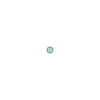

In [29]:
trkGdf['geometry'].asof(dirArrowTimes[0])

In [30]:
def createPlot(ax, extent, s=72, wpS=500,plotWind=True, lblWpt=True ,extentBuffer=buffer):
    
    boundBox = shapely.geometry.box(*extent)
    wptMask = waypointGdf['geometry'].map(lambda pt: boundBox.contains(pt))
    
    tmDelta = pd.Timedelta('1 minute')
    for tm in dirArrowTimes:
        pt1 = trkGdf['geometry'].asof(tm)
        pt2 = trkGdf['geometry'].asof(tm+tmDelta)
        arrowBuffer = 0.001
        arrow = mpl.patches.FancyArrowPatch( (pt1.x, pt1.y+arrowBuffer), (pt2.x, pt2.y+arrowBuffer) ,mutation_scale=20, zorder=-1      )
        ax.add_patch(arrow)
    
    
    ax.scatter(waypointGdf.geometry.x, waypointGdf.geometry.y, marker='s',s=wpS, c='r', label='Marker')

    if lblWpt:
        for idx,item in waypointGdf[wptMask].iterrows():
            ax.text(item['geometry'].x,item['geometry'].y,idx, va='center', ha='center', fontsize='20', fontname='serif',c='b' )
    
    ax.set_xlim(extent[0]-extentBuffer, extent[2]+extentBuffer)
    ax.set_ylim(extent[1]-extentBuffer, extent[3]+extentBuffer)
    ax.coastlines()
    
    
    trkPlt = ax.scatter(trkGdf.geometry.x,trkGdf.geometry.y, c=colorMap(norm(trkGdf['speed'])), s=s)
    
    if plotWind:
        createWindQuiver(ax)        
    


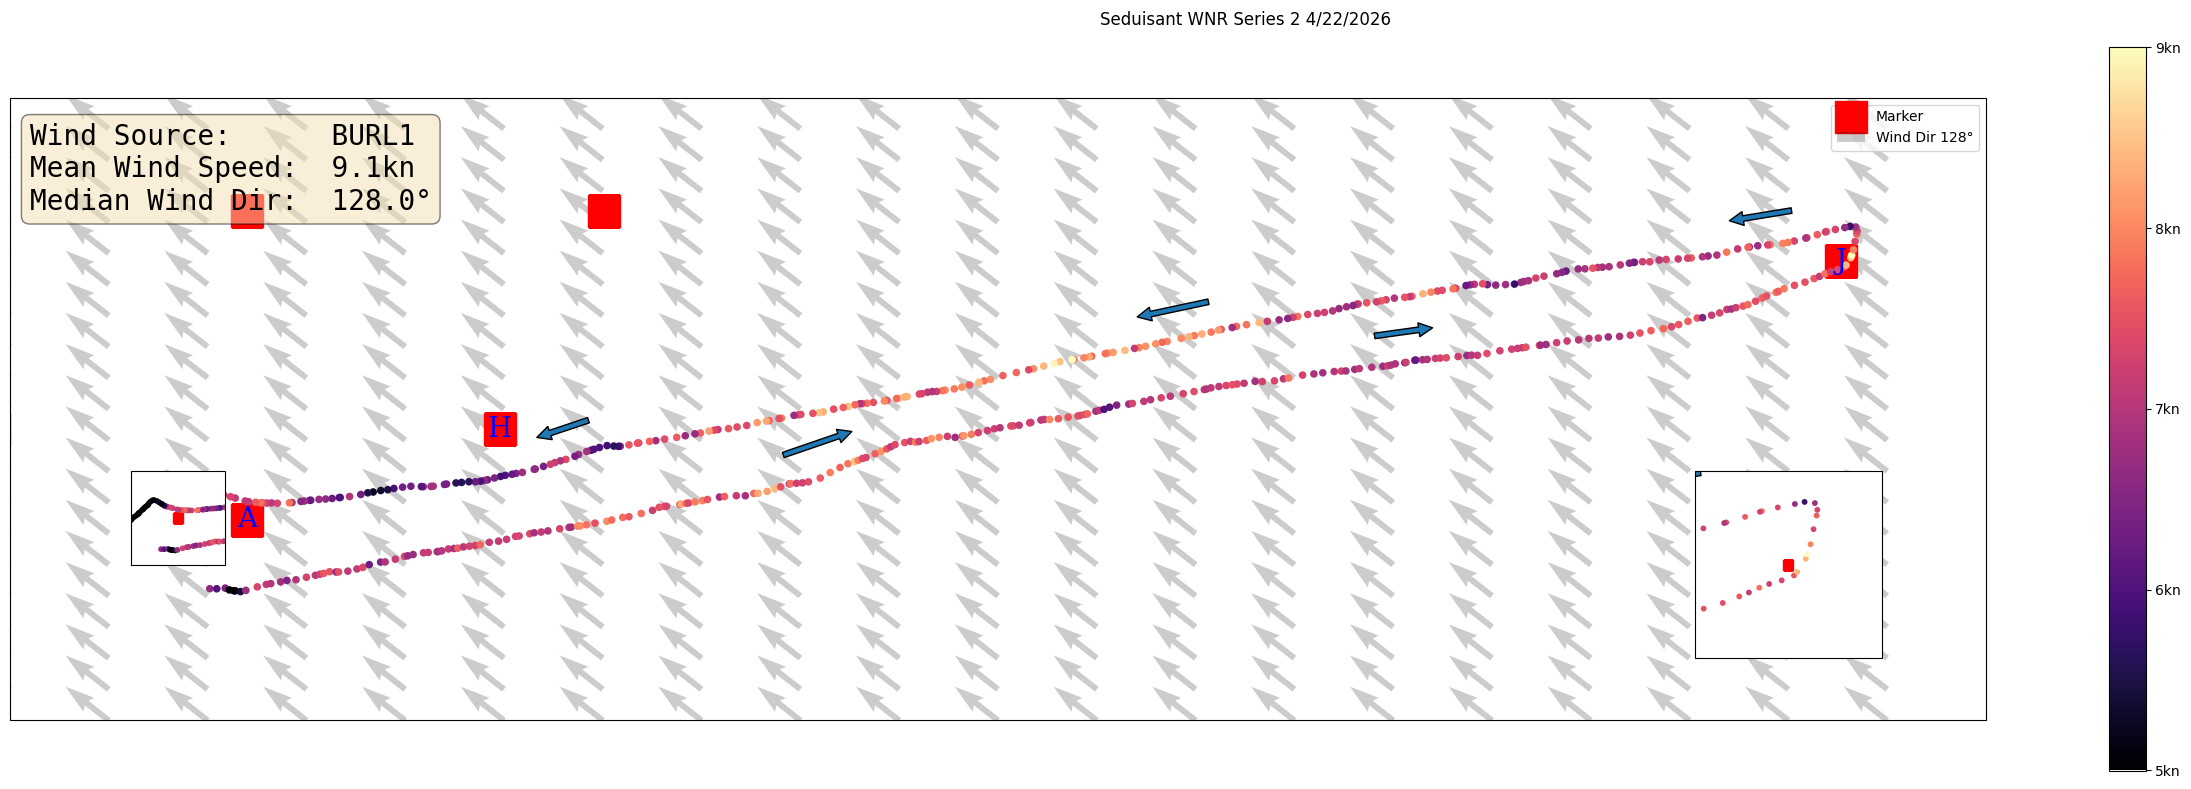

In [31]:
fig,ax = plt.subplots(1, figsize=figsize ,subplot_kw={'projection': proj})

cax = fig.colorbar( plt.cm.ScalarMappable(norm=norm, cmap=colorMap), ax=ax)
    
cax.set_ticks(colorbarTicks)
cax.set_ticklabels( [f"{int(i)}kn" for i in colorbarTicks])

createPlot(ax,s=20, extent=trkGdf.total_bounds)


wptRadius = 0.1 / 60
jExtent = waypointGdf.loc['J','geometry'].buffer(wptRadius).bounds
jInset = ax.inset_axes([0.75,0.10,0.3,0.3], projection=proj, zorder=10 )
createPlot(jInset, jExtent, s=10, wpS=50, plotWind=False, lblWpt=False, extentBuffer=0 )

wptRadius = 0.2 / 60
aExtent = waypointGdf.loc['A','geometry'].buffer(wptRadius).bounds
aInset = ax.inset_axes([0.01,0.25,0.15,0.15], projection=proj, zorder=10 )
createPlot(aInset, aExtent, s=10, wpS=50, plotWind=False, lblWpt=False, extentBuffer=0 )

#add wind speed
windStr = f"""Wind Source:      BURL1
Mean Wind Speed:  {meanWindSpeed:.1f}kn
Median Wind Dir:  {medianWind}\U000000B0"""
ax.text(0.01,0.82,windStr, transform=ax.transAxes,\
        fontsize=20,\
        fontfamily='monospace',\
       bbox={
           'boxstyle':'round',
           'facecolor':'wheat',
           'alpha':0.5
       })

ax.legend()

fig.suptitle(title)
fig.tight_layout()
fig.savefig(f"{outputPath}/{outfileBase}.jpg")
fig.savefig(f"{outputPath}/{outfileBase}.svg")

In [32]:
print(f"Last run:  {datetime.now()}")

Last run:  2026-04-24 11:53:27.834157
